In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Higgs.tools.ImplementationUtils import (
    implementChainDecayLimit,
    fromHB5Table1,
    readHEPDataCsv
)
from Higgs import bounds as HB
from Higgs import predictions as HP
from Higgs import Predictions
import os, sys
from scipy.interpolate import griddata


sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.dirname(os.getcwd()))))
import MassResolutions as resolution

# CMS 13TeV LHC

## pp -> A -> H Z -> tt ll, gg-fusion [CMS 2412.00570](https://arxiv.org/abs/2412.00570)

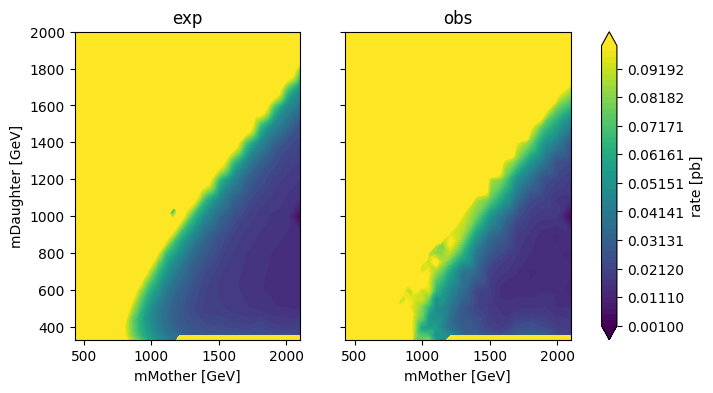

Looks good. Saving this to ggH_LHC13_CMS_138.json


In [8]:
dfs1 = readHEPDataCsv(
    "https://www.hepdata.net/download/table/ins2854935/Figure%205%20(Observed%20Limits)/2/csv"
)
dfs2 = readHEPDataCsv(
    "https://www.hepdata.net/download/table/ins2854935/Figure%205%20(Expected%20Limits)/2/csv"
)
df1 = dfs1[0]
df2 = dfs2[0]

dfR = pd.merge(
    df1, df2,
    left_on=["$m_A$ [GeV] [GeV]", "$m_H$ [GeV] [GeV]"],
    right_on=["$m_A$ [GeV] [GeV]", "$m_H$ [GeV] [GeV]"],
    validate="1:1"
).rename(
    columns={
        "$m_H$ [GeV] [GeV]": "mDaughter",
        "$m_A$ [GeV] [GeV]": "mMother",
        "Observed limits 95% CL [pb]": "obs",
        "Expected limits 95% CL [pb]": "exp",
    }
)


# interpolate onto a more reasonable grid
XX, YY = np.meshgrid(
    np.linspace(np.min(dfR.mMother), np.max(dfR.mMother), 63),
    np.linspace(np.min(dfR.mDaughter), np.max(dfR.mDaughter), 76),
)
df = pd.DataFrame(data={"mMother": XX.flatten(), "mDaughter": YY.flatten()})
df["exp"] = griddata(
    dfR[["mMother", "mDaughter"]],
    dfR.exp,  # fb to pb and remove Z>ll
    df[["mMother", "mDaughter"]],
    fill_value=1e6,
)

df["obs"] = griddata(
    dfR[["mMother", "mDaughter"]],
    dfR.obs,
    df[["mMother", "mDaughter"]],
    fill_value=1e6,
)

limitFile = implementChainDecayLimit(
    "2412.00570",
    {"production": ["ggH"], "chain": "Z", "decay": ["tt"]},
    "https://doi.org/10.17182/hepdata.150023.v2/t3",
    df,
    massResolution={
        "daughter": {"absolute": 0, "relative": 0.15},
        "mother": {"absolute": -20, "relative": 0.2},
    },
    contourfPlotArgs={
        "levels": np.linspace(1e-3, 0.1),
        "extend": "both",
    },
)

lim = HB.Limit(limitFile)